In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dbcv import dbcv
from matplotlib.ticker import MultipleLocator
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from clustergram import Clustergram
from sklearn.metrics import adjusted_rand_score

In [108]:
df = pd.read_csv('SouthGermanCredit.asc', sep = ' ')
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


Нема пропущених данних

Почнемо з кластерізації без зменшення розмірності

K=2 fitted in 0.007 seconds.
K=3 fitted in 0.012 seconds.
K=4 fitted in 0.007 seconds.
K=5 fitted in 0.008 seconds.
K=6 fitted in 0.008 seconds.
K=7 fitted in 0.018 seconds.
K=8 fitted in 0.008 seconds.
K=9 fitted in 0.006 seconds.
K=10 fitted in 0.005 seconds.


<Axes: xlabel='Number of clusters (k)', ylabel='PCA weighted mean of the clusters'>

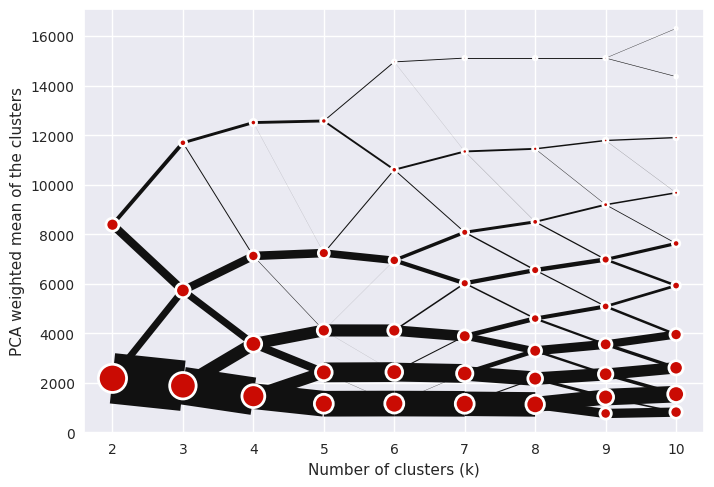

In [110]:
cgram = Clustergram(range(2, 11))
cgram.fit(df)
cgram.plot()

Дивлячись на кластерграм мабуть найркаще буде використовувати 2-3 кластери

In [111]:
clusters_kmeans = []
for i in range(2, 11):
	kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto').fit(df)
	score = silhouette_score(df, kmeans.labels_)
	clusters_kmeans.append(score)
print("Найкраща кількість кластерів для KMeans:", clusters_kmeans.index(max(clusters_kmeans)) + 2, f"({max(clusters_kmeans)})")

Найкраща кількість кластерів для KMeans: 2 (0.7216366892146989)


silhouette_score також говорить, що найкраще 2 кластери

In [112]:
df_unique = np.unique(df, axis=0, return_index=False) # Видаляємо дублікати для dbcv

clusters_dbscan = dict()
for i in np.arange(200, 301, 5):
    for j in range(3, 6):
        dbscan = DBSCAN(eps=i, min_samples=j).fit(df_unique)
        n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)	
        if n_clusters > 1:
            score = dbcv(df_unique, dbscan.labels_)
            clusters_dbscan[score] = [i, j, n_clusters]
best = max(clusters_dbscan.keys())
print(f"Найкращі параметри для DBSCAN: eps={clusters_dbscan[best][0]:.1f},",
      f"min_samples={clusters_dbscan[best][1]}, кількість кластерів = {clusters_dbscan[best][2]} ({best})")

Найкращі параметри для DBSCAN: eps=290.0, min_samples=4, кількість кластерів = 3 (0.9604244586283279)


Я проексперементував від 5 до 1000 eps, результат показав, що найкраще буде eps=290.0, min_samples=4, a кількість кластерів 3

Перейдемо до зменшенні розмірності, побудую графік втрати інформації

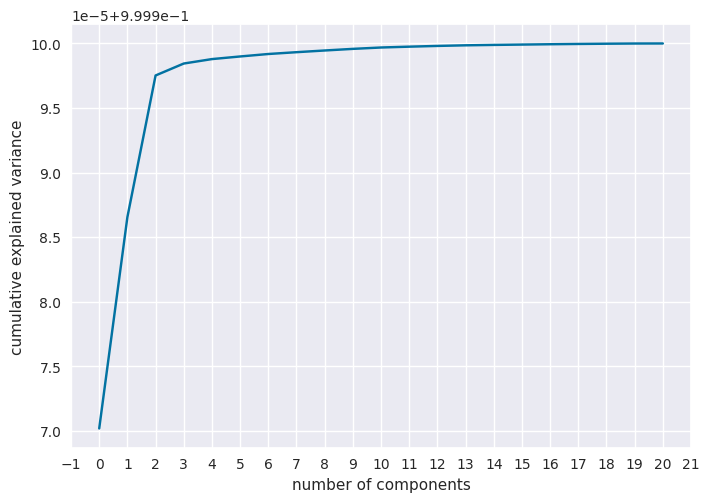

In [113]:
pca = PCA().fit(df)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.show()

При 2 компонентах зберігається десь 97% інформації, а вже на 1 компоненті до 85%, тож буде оптимально використовувати 2 компонети

In [114]:
pca = PCA(n_components=2)
X = pca.fit_transform(df)

K=2 fitted in 0.114 seconds.
K=3 fitted in 0.004 seconds.
K=4 fitted in 0.003 seconds.
K=5 fitted in 0.003 seconds.
K=6 fitted in 0.004 seconds.
K=7 fitted in 0.005 seconds.
K=8 fitted in 0.003 seconds.
K=9 fitted in 0.005 seconds.
K=10 fitted in 0.004 seconds.


<Axes: xlabel='Number of clusters (k)', ylabel='PCA weighted mean of the clusters'>

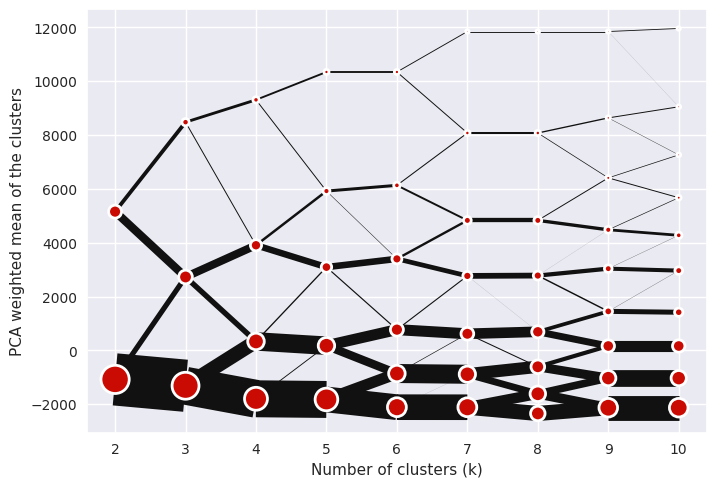

In [115]:
cgram = Clustergram(range(2, 11))
cgram.fit(X)
cgram.plot()

In [116]:
clusters_kmeans = []
for i in range(2, 11):
	kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto').fit(X)
	score = silhouette_score(X, kmeans.labels_)
	clusters_kmeans.append(score)
print("Найкраща кількість кластерів для KMeans:", clusters_kmeans.index(max(clusters_kmeans)) + 2, f"({max(clusters_kmeans)})")

Найкраща кількість кластерів для KMeans: 2 (0.7216756348141831)


Для KMeans досі найраще 2 кластери,але score зовсім трішечки піднявся, спробую перевірити DBSCAN

In [117]:
X_unique = np.unique(X, axis=0, return_index=False) # Видаляємо дублікати для dbcv

clusters_dbscan = dict()
for i in np.arange(200, 301, 5):
    for j in range(3, 6):
        dbscan = DBSCAN(eps=i, min_samples=j).fit(X_unique)
        n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)	
        if n_clusters > 1:
            score = dbcv(X_unique, dbscan.labels_)
            clusters_dbscan[score] = [i, j, n_clusters]
best = max(clusters_dbscan.keys())
print(f"Найкращі параметри для DBSCAN: eps={clusters_dbscan[best][0]:.1f},",
      f"min_samples={clusters_dbscan[best][1]}, кількість кластерів = {clusters_dbscan[best][2]} ({best})")

Найкращі параметри для DBSCAN: eps=290.0, min_samples=4, кількість кластерів = 3 (0.8837693648673884)


Параметри для DBSCAN залишились тіж самі, але score, трохи зменшился

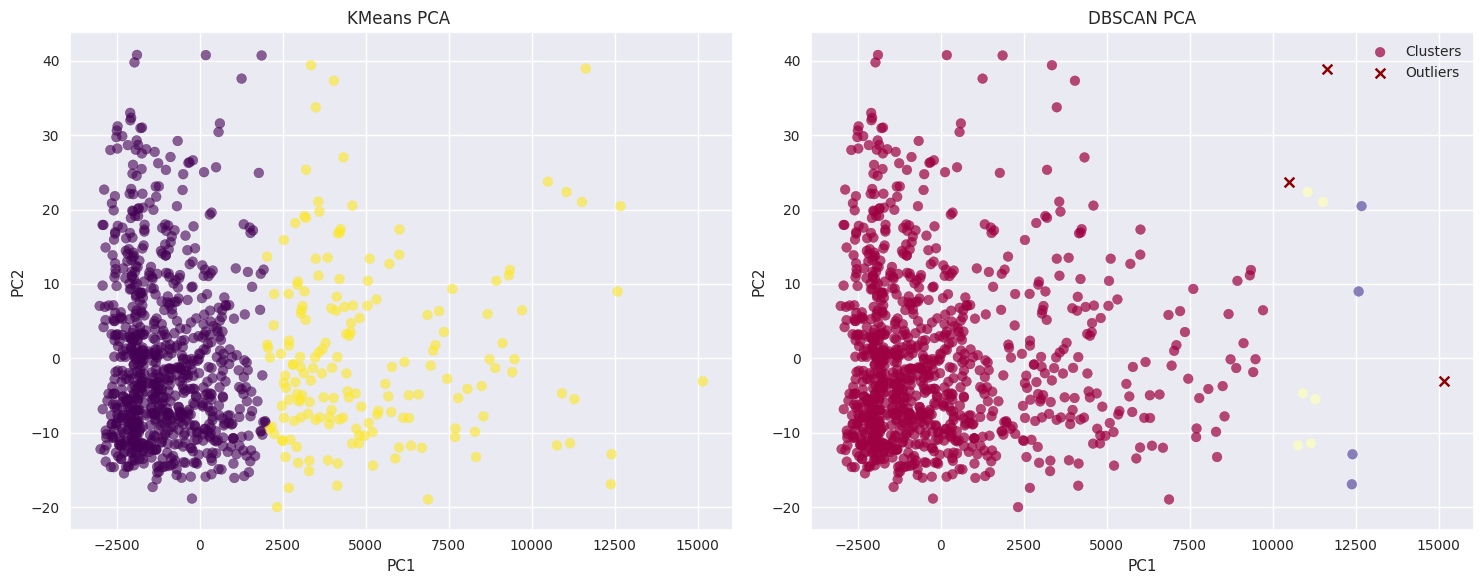

In [118]:
kmeans_best = KMeans(n_clusters=2, random_state=42, n_init='auto')
labels_kmeans = kmeans_best.fit_predict(X)

dbscan_best = DBSCAN(eps=290, min_samples=4)
labels_dbscan = dbscan_best.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Графік для K-Means
axes[0].scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=50, alpha=0.6)
axes[0].set_title(f'KMeans PCA ')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Графік для DBSCAN
outliers_mask = labels_dbscan == -1
core_mask = labels_dbscan != -1

axes[1].scatter(X[core_mask, 0], X[core_mask, 1], 
				c=labels_dbscan[core_mask], 
				cmap='Spectral',
    			alpha=0.7, label='Clusters')

axes[1].scatter(X[outliers_mask, 0], X[outliers_mask, 1], 
                c='darkred', alpha=1, marker='x', label='Outliers')

axes[1].set_title(f'DBSCAN PCA')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

plt.show()

Так виглядає розбиті данні, звісно вже не можемо сказати за що відповідає кожна координата, але візуально вийшло так, як на мене KMeans зробив краще, адже в нас є два великі класи, коли в DBScan один величезний кластер, 2 два маленькі, можливо завелика відстань в eps, не дивлячись на метрику DBCV

Для порівняння я візьму KMeans до та після розбиття, та порівняю їх за допомогою ARI

In [ ]:
kmeans_full = KMeans(n_clusters=2, random_state=42).fit(df)
labels_full = kmeans_full.labels_

# Порівняння за допомогою ARI
ari_score = adjusted_rand_score(labels_full, labels_kmeans)

print(f"ARI між повним і PCA n = 2 (97%): {ari_score:.2f}")


ARI між повним і PCA n = 2: 1.00


In [121]:
X = PCA(n_components=1).fit_transform(df)
labels_pca = KMeans(n_clusters=2, random_state=42).fit(X).labels_

ari_score = adjusted_rand_score(labels_full, labels_pca)
print(f"ARI між повним і PCA n = 1 (85%): {ari_score:.2f}")

ARI між повним і PCA n = 1 (85%): 1.00


Висновок: при кластеризації цього дата сету ми можемо зменшити його розмірність до 1 колонки